# 03 Time Slicing: Querying Your Cube Across Time and Space

**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota Nation), South Dakota  
**Prerequisites:** Notebooks 00, 01, 02  

## What This Notebook Covers
One of the core strengths of a data cube is the ability to ask precise
temporal questions without writing complex loops or filtering code.
This notebook teaches the main time-slicing patterns:

1. **Point selection**: what was NDVI on a specific date?
2. **Range selection**: what was NDVI during a specific period?
3. **Conditional selection**: which time steps meet a condition?
4. **Groupby operations**: summarize by year, month, season
5. **Anomaly detection**: which years were unusually dry?
6. **Rolling windows**: smooth the data to see trends

All examples use the real Pine Ridge NDVI cube from notebook 02.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from src.cube_utils import (
    fetch_ndvi_timeseries,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    compute_anomaly,
    CACHE_DIR,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

PINE_RIDGE_LAT =  43.35
PINE_RIDGE_LON = -102.09
GROWING_MONTHS = [5, 6, 7, 8, 9]

In [2]:
# Load or rebuild the NDVI cube from notebook 02
cube_path = CACHE_DIR / "pine_ridge_ndvi_cube.nc"

if cube_path.exists():
    cube   = xr.open_dataset(cube_path)
    ndvi   = cube["ndvi"]
    print(f"Cube loaded from {cube_path.name}")
else:
    print("Cube not found: fetching NDVI data...")
    ndvi_df = fetch_ndvi_timeseries(
        lat=PINE_RIDGE_LAT, lon=PINE_RIDGE_LON,
        start_year=2000, end_year=2023,
        site_name="pine_ridge",
    )
    ndvi = timeseries_to_dataarray(ndvi_df, name="ndvi")
    cube = xr.Dataset({"ndvi": ndvi})

print(f"Time steps: {len(ndvi.time)}")
print(f"Date range: {str(ndvi.time.values[0])[:10]} to {str(ndvi.time.values[-1])[:10]}")

Cube loaded from pine_ridge_ndvi_cube.nc
Time steps: 549
Date range: 2000-02-18 to 2023-12-19


---
## Pattern 1: Point Selection

Select a single value by its coordinate label.

In [3]:
# Select by exact date
# .sel() selects by label (this is the xarray way)

val = ndvi.sel(time="2012-07-28", method="nearest")
print(f"NDVI nearest to 2012-07-28: {float(val):.4f}")
print(f"Actual date returned: {str(val.time.values)[:10]}")
print()
print("2012 was an extreme drought year in South Dakota.")
print("NDVI in late July should reflect that stress.")

NDVI nearest to 2012-07-28: 0.4149
Actual date returned: 2012-07-27

2012 was an extreme drought year in South Dakota.
NDVI in late July should reflect that stress.


In [12]:
# Compare same date across years ex. how unusual was 2012?
july_vals = {}
for year in range(2000, 2024):
    try:
        v = float(ndvi.sel(
            time=f"{year}-07-28", method="nearest"
        ))
        july_vals[year] = v
    except Exception:
        pass

july_df   = pd.Series(july_vals).sort_index()
july_mean = july_df.mean()

print("Late July NDVI comparison (nearest available date each year):")
for yr, val in july_df.items():
    flag = " <- drought" if val < july_mean - july_df.std() else ""
    print(f"  {yr}: {val:.4f}{flag}")
print(f"\nLong-term mean: {july_mean:.4f}")

Late July NDVI comparison (nearest available date each year):
  2000: 0.5427
  2001: 0.6064
  2002: 0.3483 <- drought
  2003: 0.4480
  2004: 0.3669 <- drought
  2005: 0.5183
  2006: 0.3890 <- drought
  2007: 0.4104 <- drought
  2008: 0.5436
  2009: 0.5690
  2010: 0.5250
  2011: 0.6279
  2012: 0.4149 <- drought
  2013: 0.5458
  2014: 0.6418
  2015: 0.6829
  2016: 0.6068
  2017: 0.5208
  2018: 0.6006
  2019: 0.6953
  2020: 0.6509
  2021: 0.4441
  2022: 0.4915
  2023: 0.6606

Long-term mean: 0.5355


---
## Pattern 2: Range Selection

Select all values within a time range using `slice()`.

2012 observations: 23
2010 observations: 23


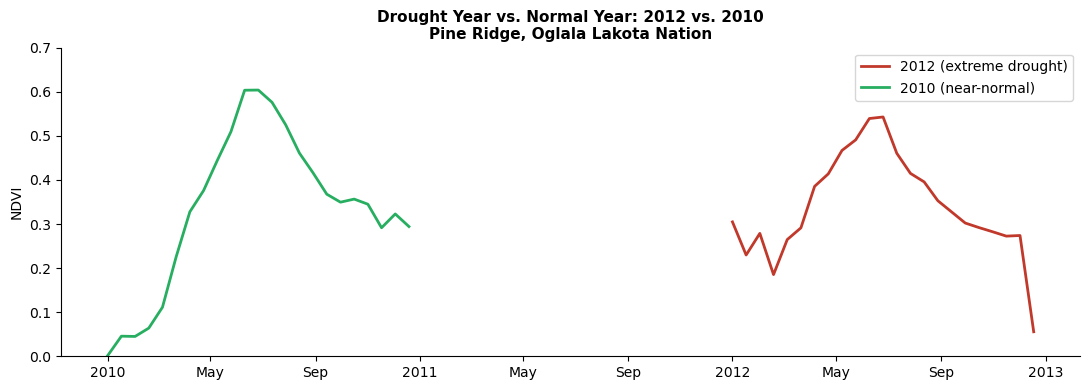


Growing season NDVI 2012: 0.4294
Growing season NDVI 2010: 0.4857
Difference: -0.0562 NDVI units


In [5]:
# Select the 2012 drought year
drought_2012 = ndvi.sel(time=slice("2012-01-01", "2012-12-31"))
normal_2010  = ndvi.sel(time=slice("2010-01-01", "2010-12-31"))

print(f"2012 observations: {len(drought_2012)}")
print(f"2010 observations: {len(normal_2010)}")

fig, ax = plt.subplots(figsize=(11, 4))

# Plot both years aligned by day-of-year
drought_2012.plot(
    ax=ax, color="#C0392B", linewidth=2,
    label="2012 (extreme drought)",
)
normal_2010.plot(
    ax=ax, color="#27AE60", linewidth=2,
    label="2010 (near-normal)",
)

ax.set_xlabel("")
ax.set_ylabel("NDVI")
ax.set_title(
    "Drought Year vs. Normal Year: 2012 vs. 2010\n"
    "Pine Ridge, Oglala Lakota Nation",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.7)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Compute the difference
gs_2012 = float(drought_2012.sel(
    time=drought_2012["time"].dt.month.isin(GROWING_MONTHS)
).mean())
gs_2010 = float(normal_2010.sel(
    time=normal_2010["time"].dt.month.isin(GROWING_MONTHS)
).mean())
print(f"\nGrowing season NDVI 2012: {gs_2012:.4f}")
print(f"Growing season NDVI 2010: {gs_2010:.4f}")
print(f"Difference: {gs_2012 - gs_2010:+.4f} NDVI units")

---
## Pattern 3: Conditional Selection

Select time steps that meet a condition using `.where()`.

In [13]:
# Which observations had NDVI below the drought threshold?
DROUGHT_NDVI_THRESHOLD = 0.25

# .where() keeps values meeting the condition, sets others to NaN
drought_obs = ndvi.where(ndvi < DROUGHT_NDVI_THRESHOLD)

# Count stressed observations by year
stressed_counts = (
    drought_obs
    .groupby("time.year")
    .count()
    .rename("stressed_observations")
)

print(f"Observations with NDVI < {DROUGHT_NDVI_THRESHOLD} (vegetation stress):")
stress_df = stressed_counts.to_dataframe().reset_index()
for _, row in stress_df.sort_values("stressed_observations", ascending=False).head(10).iterrows():
    bar = "█" * int(row["stressed_observations"])
    print(f"  {int(row['year'])}: {int(row['stressed_observations']):>2} obs  {bar}")

Observations with NDVI < 0.25 (vegetation stress):
  2001:  9 obs  █████████
  2003:  8 obs  ████████
  2013:  8 obs  ████████
  2009:  8 obs  ████████
  2023:  7 obs  ███████
  2008:  7 obs  ███████
  2000:  6 obs  ██████
  2002:  6 obs  ██████
  2019:  6 obs  ██████
  2010:  6 obs  ██████


---
## Pattern 4: Groupby Operations

Summarize data by time components such as year, month, season.

In [14]:
# Groupby year: annual mean
annual_mean = ndvi.groupby("time.year").mean()

# Groupby month: seasonal climatology
monthly_clim = ndvi.groupby("time.month").mean()

# Groupby decade: long-term change
ndvi_with_decade = ndvi.assign_coords(
    decade=("time", (ndvi["time"].dt.year.values // 10 * 10))
)
decadal_mean = ndvi_with_decade.groupby("decade").mean()

print("Decadal mean growing season NDVI at Pine Ridge:")
for decade, val in zip(decadal_mean.decade.values, decadal_mean.values):
    bar = "█" * int(val * 50)
    print(f"  {decade}s: {val:.4f}  {bar}")

Decadal mean growing season NDVI at Pine Ridge:
  2000s: 0.3370  ████████████████
  2010s: 0.3794  ██████████████████
  2020s: 0.3929  ███████████████████


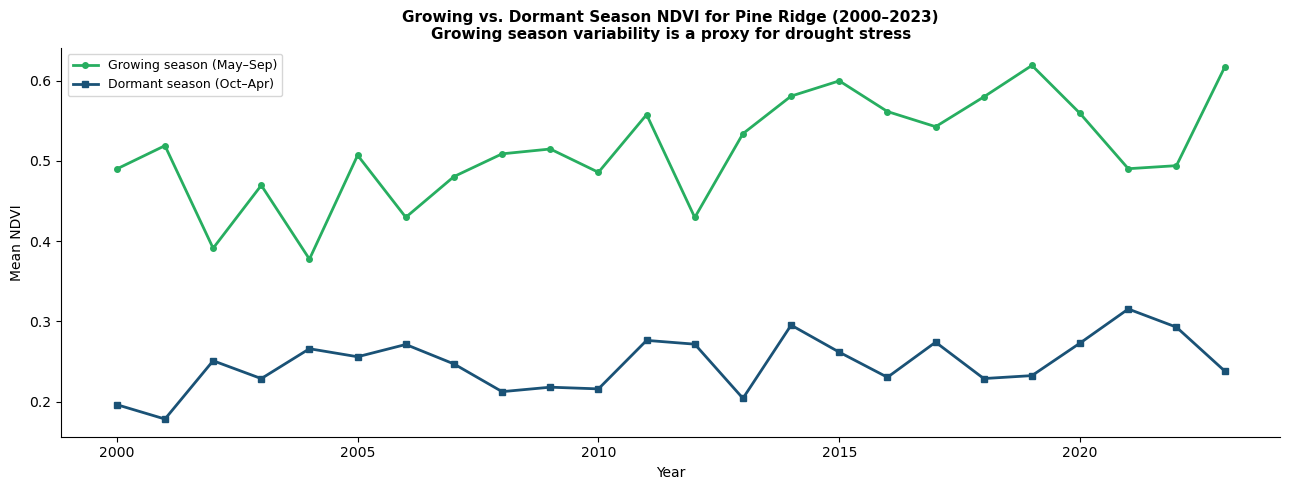

In [8]:
# Seasonal breakdown (growing season vs. dormant season)
growing  = ndvi.sel(time=ndvi["time"].dt.month.isin(GROWING_MONTHS))
dormant  = ndvi.sel(time=~ndvi["time"].dt.month.isin(GROWING_MONTHS))

gs_annual = growing.groupby("time.year").mean()
dm_annual = dormant.groupby("time.year").mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(gs_annual.year, gs_annual.values,
        color="#27AE60", linewidth=2, marker="o",
        markersize=4, label="Growing season (May–Sep)")
ax.plot(dm_annual.year, dm_annual.values,
        color="#1A5276", linewidth=2, marker="s",
        markersize=4, label="Dormant season (Oct–Apr)")

ax.set_xlabel("Year")
ax.set_ylabel("Mean NDVI")
ax.set_title(
    "Growing vs. Dormant Season NDVI for Pine Ridge (2000–2023)\n"
    "Growing season variability is a proxy for drought stress",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Pattern 5: Anomaly Detection

An anomaly is the departure from the long-term average.
Positive anomaly = greener than usual. Negative = less green than usual.

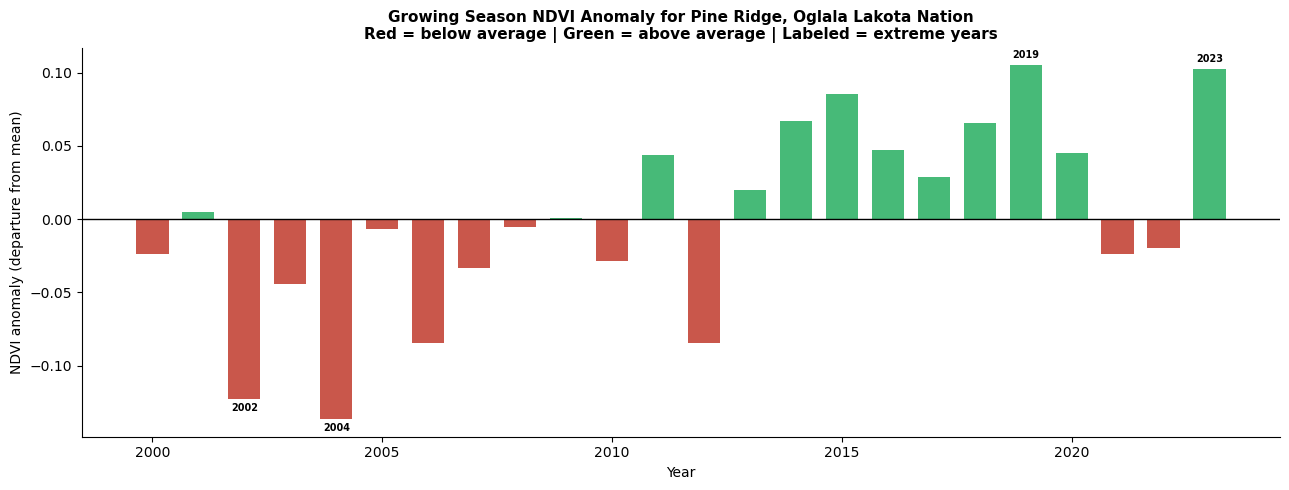

Most negative anomaly years (driest/least green):
  2004: -0.1365
  2002: -0.1229
  2012: -0.0846
  2006: -0.0844
  2003: -0.0445


In [9]:
# Compute growing season NDVI anomalies
annual_gs = compute_growing_season_mean(ndvi, months=GROWING_MONTHS)
anomaly   = compute_anomaly(annual_gs)

fig, ax = plt.subplots(figsize=(13, 5))

years  = anomaly.year.values
values = anomaly.values

colors = ["#C0392B" if v < 0 else "#27AE60" for v in values]
ax.bar(years, values, color=colors, alpha=0.85, width=0.7)
ax.axhline(0, color="black", linewidth=1)

# Label the most extreme years
for yr, val in zip(years, values):
    if abs(val) > np.std(values) * 1.5:
        ax.annotate(
            str(int(yr)),
            (yr, val + (0.005 if val > 0 else -0.008)),
            ha="center", fontsize=7, fontweight="bold",
        )

ax.set_xlabel("Year")
ax.set_ylabel("NDVI anomaly (departure from mean)")
ax.set_title(
    "Growing Season NDVI Anomaly for Pine Ridge, Oglala Lakota Nation\n"
    "Red = below average | Green = above average | Labeled = extreme years",
    fontsize=11, fontweight="bold",
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("Most negative anomaly years (driest/least green):")
anom_df = pd.Series(values, index=years.astype(int)).sort_values()
for yr, val in anom_df.head(5).items():
    print(f"  {yr}: {val:+.4f}")

---
## Pattern 6: Rolling Windows

A rolling window computes a statistic over a sliding time window.
It smooths out short-term noise and reveals longer-term trends.

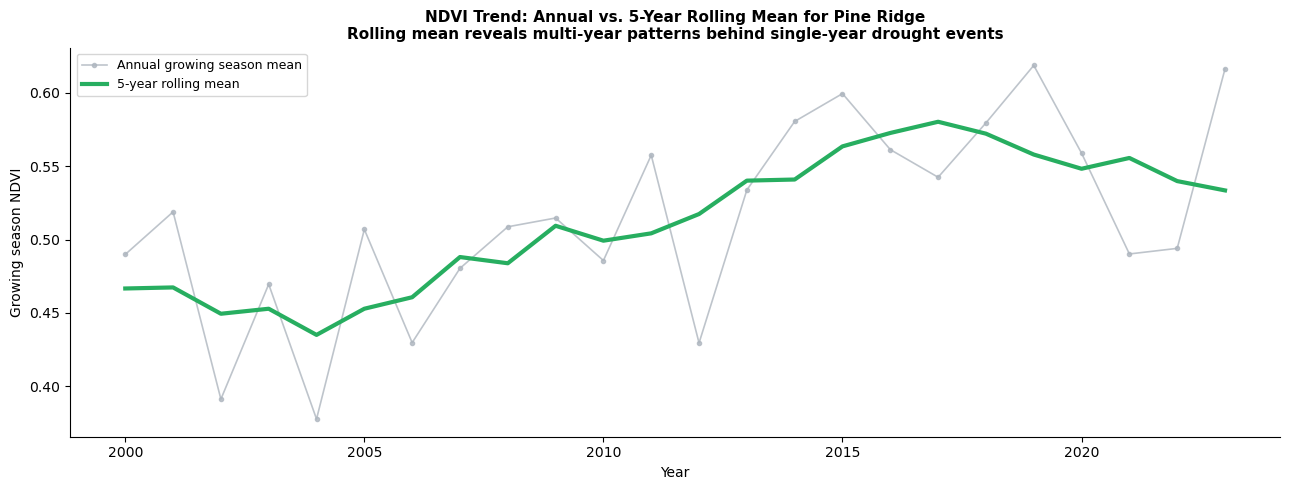

In [10]:
# 5-year rolling mean of growing season NDVI
# This smooths out individual drought years to show the multi-year trend

# from compute_growing_season_mean above
annual_gs_da = annual_gs  

# Rolling mean (center=True centers the window on each year)
rolling_5yr = annual_gs_da.rolling(year=5, center=True, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(annual_gs_da.year, annual_gs_da.values,
        color="#AEB6BF", linewidth=1.2, alpha=0.8,
        marker="o", markersize=3, label="Annual growing season mean")
ax.plot(rolling_5yr.year, rolling_5yr.values,
        color="#27AE60", linewidth=3,
        label="5-year rolling mean")

ax.set_xlabel("Year")
ax.set_ylabel("Growing season NDVI")
ax.set_title(
    "NDVI Trend: Annual vs. 5-Year Rolling Mean for Pine Ridge\n"
    "Rolling mean reveals multi-year patterns behind single-year drought events",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [11]:
# Bonus: resample to monthly means by converting 16-day to monthly
# This is useful when combining NDVI with monthly climate data (notebook 04)

ndvi_monthly = ndvi.resample(time="MS").mean()

print(f"Original: {len(ndvi)} observations (16-day)")
print(f"Resampled: {len(ndvi_monthly)} observations (monthly)")
print()
print("Monthly resampling makes it easier to align NDVI with climate")
print("variables like precipitation and temperature, which we add in")
print("notebook 04.")

# Save the monthly cube for use in notebook 04
monthly_cube = xr.Dataset(
    {"ndvi": ndvi_monthly},
    attrs=cube.attrs,
)
monthly_cube.attrs["temporal_res"] = "monthly (resampled from 16-day)"
monthly_path = CACHE_DIR / "pine_ridge_ndvi_monthly.nc"
monthly_cube.to_netcdf(monthly_path)
print(f"\nMonthly cube saved to {monthly_path.name}")

Original: 549 observations (16-day)
Resampled: 287 observations (monthly)

Monthly resampling makes it easier to align NDVI with climate
variables like precipitation and temperature, which we add in
notebook 04.

Monthly cube saved to pine_ridge_ndvi_monthly.nc


## Summary: Time Slicing Patterns

| Pattern | xarray method | When to use |
|---|---|---|
| Point selection | `.sel(time="2012-07-28")` | Single date |
| Range selection | `.sel(time=slice("2012-01-01", "2012-12-31"))` | A period |
| Conditional | `.where(ndvi < 0.25)` | Filter by value |
| Groupby year | `.groupby("time.year").mean()` | Annual summaries |
| Groupby month | `.groupby("time.month").mean()` | Seasonal patterns |
| Anomaly | `da - da.mean()` | Departures from normal |
| Rolling mean | `.rolling(year=5).mean()` | Smoothed trends |
| Resample | `.resample(time="MS").mean()` | Change temporal resolution |

## Discussion Questions

1. The anomaly chart labels the most extreme years. Do those years
   correspond to what you know about drought history in South Dakota?
   If you don't know the drought history, how would you find out?

2. The 5-year rolling mean smooths out individual drought years.
   What are the advantages and disadvantages of showing rolling means
   to a community audience compared to showing raw annual values?

3. The growing season in this tutorial is defined as May–September.
   That's a scientific definition based on grass growth phenology.
   How might Oglala Lakota knowledge holders define the "season that
   matters" for land health differently? Why would that matter for
   how you set up this analysis?

## Next Notebook
**04 Multi-Variable Cube:** We add real temperature and precipitation
data (gridMET) to the cube alongside NDVI and start asking compound
questions like "did vegetation decline because it was hot, dry, or both?"